In [1]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using DifferentialEquations
using Plots

In [2]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C'
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

eig_full (generic function with 1 method)

In [3]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.1
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
n = -5
num = 1
R = 100
omega = 7.9/R
be = n/R
Ma = Mr/R
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)


┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

([0.0; 0.0002824811174422547; … ; -4.758050982560994e-24; -4.758050982560994e-24;;], [0.0; -0.00034117928292027233; … ; -1.0; -1.0;;], [2.3203360532432654e-25; -1.5650496800292764e-7; … ; -0.8844733964150246; -0.8844733964150246;;], [1.0000000000000089; 1.0000005175325009; … ; 0.9999999791844155; 0.9999999791844155;;], [0.9999999999999911; 0.9999994824677669; … ; 1.0000000208155848; 1.0000000208155848;;], [0.0; 0.0005539326468201291; … ; 20.0; 20.0;;], [-0.6666666666666725; -0.6666670116883339; … ; -0.6666666527896103; -0.6666666527896103;;], [1.3888888888889013; 1.388889607684029; … ; 1.3888888599783549; 1.3888888599783549;;], [-2970.151515151124 3611.390030573762 … -0.9093198110834142 0.45454545454545453; -902.4262223900014 451.0994992567002 … 0.45456220808173375 -0.2272238764335357; … ; 4.436834640202506e-8 -8.875904163768224e-8 … -8.80829037817145e-5 0.00017621017590984625; -0.0 0.0 … -0.0 0.0], [5.295001504873778e6 -8.41357312149442e6 … 5384.226905905448 -2691.424943501555; 2.4441

In [4]:
Zero = zeros(size(L0,1),size(L0,2))
eye = I(size(L0,1))
H0 = [L0 L1;Zero -eye]
H1 = [Zero -L2 ; -eye Zero]
C = eigen(H0,H1)
H0_A = [A0 A1;Zero -eye]
H1_A = [Zero -A2 ; -eye Zero]
C_A = eigen(H0_A,H1_A)


UndefVarError: UndefVarError: `L0` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [5]:
val = filter(x -> abs(imag(x)) < 0.05 && abs(real(x))>0.1, C.values)
val_A = filter(x -> abs(imag(x)) < 0.05 && abs(real(x))>0.1, C_A.values)
index = findall(C.values .== val[1])
index_A = findall(C_A.values .== val_A[1])
vec = C.vectors[:,index]
vec_A = C_A.vectors[:,index_A]
vec_half = C.vectors[1:491,index]
vec_A_half = C_A.vectors[1:491,index_A]
vel_full,vel = eig_full(vec,N_cheb,1)
vel_full_A,vel_A = eig_full(vec_A,N_cheb,1)


UndefVarError: UndefVarError: `C` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [6]:
@show val,val_A

UndefVarError: UndefVarError: `val` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

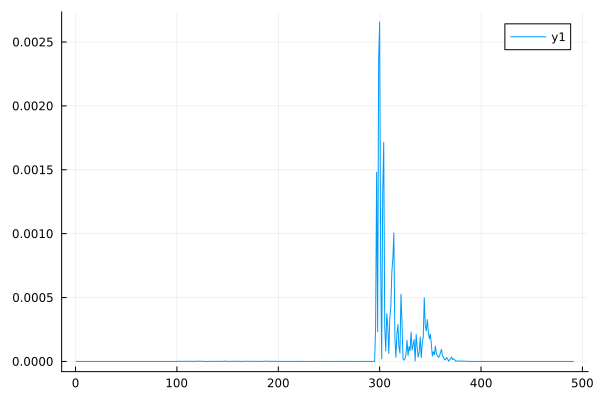

In [10]:
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = 0.2, neigs = 1 ,maxit = 500 , tol=1e-13)
vel_full,vel = eig_full(eigvec,N_cheb,1)
res = (L0 +  (eigval[1])*L1 + (eigval[1])^2*L2) * eigvec[:,1];
plot(abs.(res))

In [ ]:
A0_raw = cof.D1' + (im * be * cof.B)' - (im * omega * cof.Ta)' - (be^2 * cof.Vyy)' - cof.dC' - (im *be*cof.dVyz)' + cof.d2Vzz' - (cof.C + im * be * cof.dVyz - 2 * cof.dVzz)' * kron(I(5),D) + cof.Vzz' * kron(I(5),D2)
A1_raw = (im * cof.A)' - (be * cof.Vxy)' - (im * cof.dVxz)' - (im * cof.Vxz)' * kron(I(5),D) 
A2_raw = -cof.Vxx'
A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
nep = PEP([A0,A1,A2]); 
eigval_A,eigvec_A = iar(nep,σ = 0.2, neigs = 1 ,maxit = 500,tol=1e-14)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
@show eigval,eigval_A 

(eigval, eigval_A) = (ComplexF64[0.2665095475063517 - 0.010489400413879373im], ComplexF64[0.2662944311201035 + 0.010618871871452173im])


(ComplexF64[0.2665095475063517 - 0.010489400413879373im], ComplexF64[0.2662944311201035 + 0.010618871871452173im])

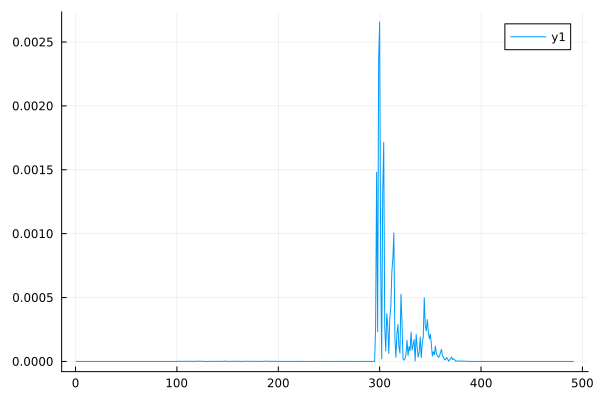

In [13]:
res = (L0 +  (eigval[1])*L1 + (eigval[1])^2*L2) * eigvec[:,1];
plot(abs.(res))

In [166]:
Q = abs.(eigvec_A[:,1]' * (L1 + (eigval[1]+eigval_A[1]) * L2) * eigvec[:,1])

6.22591393271613

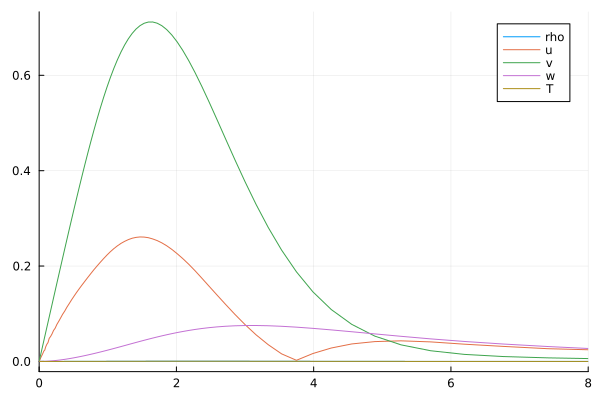

In [149]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel[2]),label = "u")
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

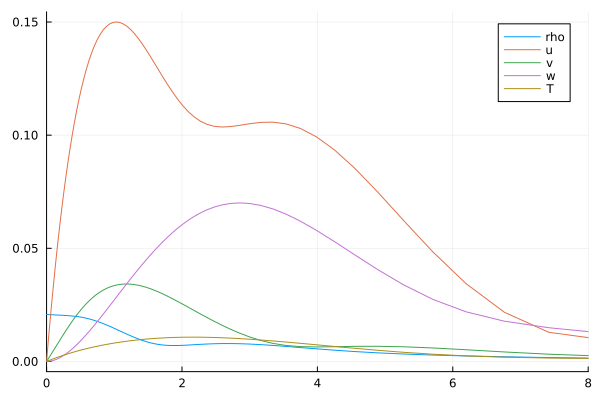

In [16]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel_A[2]),label = "u")
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [ ]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
n = 32
num = 1
R = 100
omega = 0/R
be = n/R
Ma = Mr/R
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

In [ ]:
coff = [0 0 0 0 0 0 0]
for R = 280 : 2 : 360
    be = 32/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep, σ = 0.5, neigs = 1,maxit = 500,tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    A0_raw = cof.D1' + (im * be * cof.B)' - (im * omega * cof.Ta)' - (be^2 * cof.Vyy)' - cof.dC' - (im *be*cof.dVyz)' + cof.d2Vzz' - (cof.C + im * be * cof.dVyz - 2 * cof.dVzz)' * kron(I(5),D) + cof.Vzz' * kron(I(5),D2)
    A1_raw = (im * cof.A)' - (be * cof.Vxy)' + (im * cof.dVxz)' - (im * cof.Vxz)' * kron(I(5),D) 
    A2_raw = -cof.Vxx'
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval_A,eigvec_A = iar(nep,σ = 0.5, neigs = 1 ,maxit = 500,tol=1e-13)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
    Q = abs(eigvec_A[:,1]' * (L1 + (eigval[1]+eigval_A[1]) * L2) * eigvec[:,1])    
    x0 = R
    # u_wall = -(D*F)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # v_wall = -(D*G)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    u_wall = -(be/2*pi) * (D*F)[1]
    v_wall = -(be/2*pi) * (D*G)[1]
    w_wall = 0
    T_wall = -(be/2*pi) * (D*T)[1]
    item_1 = R * abs(rho[1,1] * vel_A[1][1]) * v_wall
    item_2 = (Tw) * abs.(D*vel_A[2])[1] * u_wall
    item_3 = (3Tw/4) * abs.(D*vel_A[3])[1] * v_wall
    item_4 = (Tw/gamma) * abs.(D*vel_A[5])[1] * T_wall
    BC = item_1 + item_2 + item_3
    Cr = abs(-im * BC/Q)
    coff = [coff;[R Cr Q item_1 item_2 item_3 item_4]]
    writedlm("Cr_lof.dat",coff[2:end,:])
end

In [ ]:
plot(real(coff[2:end,1]),real(coff[2:end,2]))
# plot!(real(coff[2:end,1]),abs.(coff[2:end,3]))